In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from datasets import load_dataset
import ast


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Phython\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [10]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US['salary_year_avg'].sample(10)

279218     87500.0
285614     75000.0
582259     85000.0
614864    115000.0
263283    117302.0
433971     67500.0
734491     68000.0
539548     72500.0
762660     90000.0
404225    100000.0
Name: salary_year_avg, dtype: float64

<Axes: >

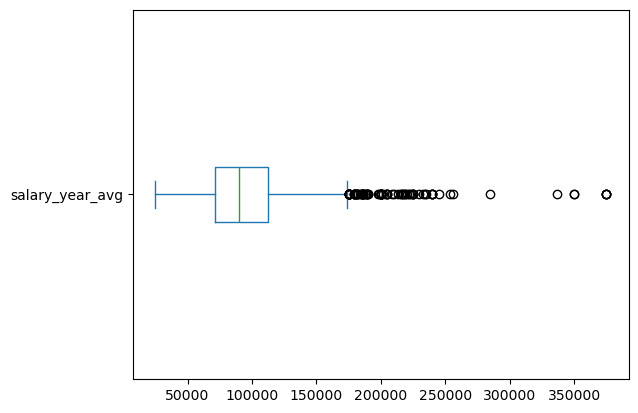

In [13]:
df_DA_US['salary_year_avg'].plot(kind='box', vert=False)

{'whiskers': [<matplotlib.lines.Line2D at 0x210d119afd0>,
 'caps': [<matplotlib.lines.Line2D at 0x210d119b250>,
 'boxes': [<matplotlib.lines.Line2D at 0x210d119ae90>],
 'medians': [<matplotlib.lines.Line2D at 0x210d119b4d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x210d119b610>],
 'means': []}

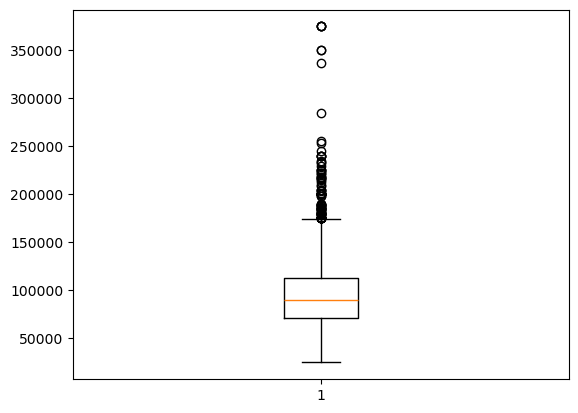

In [12]:
plt.boxplot(df_DA_US['salary_year_avg'])

C:\Users\USER\AppData\Local\Temp\ipykernel_908\3549944250.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


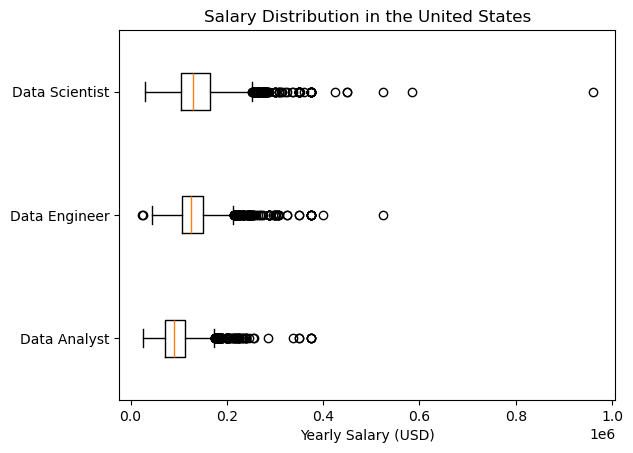

In [41]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short']== job_title]['salary_year_avg'] for job_title in job_titles]


plt.boxplot(job_list, labels=job_titles, vert=False)

plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary (USD)')

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_908\2606926041.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(job_list, labels=job_titles, vert=False)


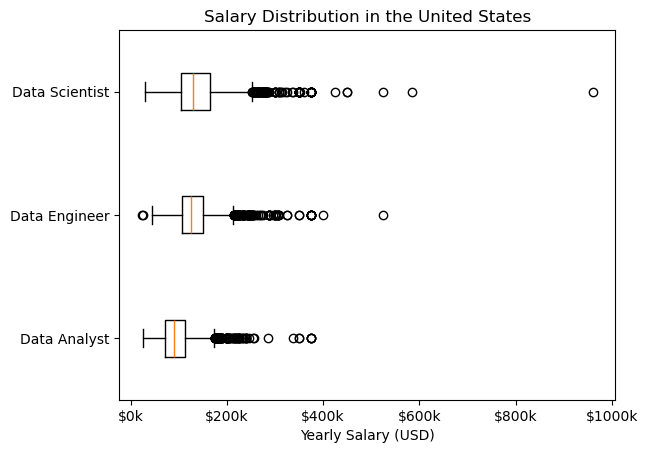

In [42]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [
    df_US[df_US['job_title_short'] == job_title]['salary_year_avg']
    for job_title in job_titles
]

fig, ax = plt.subplots()

ax.boxplot(job_list, labels=job_titles, vert=False)

ax.set_title('Salary Distribution in the United States')
ax.set_xlabel('Yearly Salary (USD)')

# ✅ Apply formatter to x-axis (not y-axis)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

plt.show()

In [18]:
df_US.value_counts('job_title_short')

job_title_short
Data Scientist    4553
Data Analyst      4350
Data Engineer     2915
Name: count, dtype: int64